# SNL SWAN WAVE SURROGATE

***

### Abstract

 During the world's transition to green energy, wave energy shows significant untapped energy potential. In order to properly harness this energy, significant development is necessary to generate power cost effectively. The phyisical position of Wave Energy Converters (WECs) inside a wave energy farm is vital. Since WEC devices extract energy from waves, the devices create an energy deficit in the incident wave direction behind the WEC device. To maximize energy production of each WEC array, the position of each WEC device should be managed to minimize energy loss in down-field devices. Current WEC array optimization methods have high fidelity, but have high computational costs, and scale poorly to larger arrays. In this paper, the wave wakes are individually computed ahead of time, and are combined when calculating the array dynamics, trading some accuracy for much faster computation speed.

### Introduction

Demand for energy is rapidly expanding globabally, necessitating the expansion of energy supply. Measures should be taken so that the energy demand can be met in a sustainable manner. One promising method for green energy generation are Wave Energy Converters. While the current levelized cost of energy of WEC devices is relatively high, projections show that levelized costs in areas with good wave energy resource could reach parity with Offshore Wind Farm in the 2030s [1]. Furthermore, the total theoretical wave energy resource is estimated at 3300 TWh/yr [2]. Accessing and using this large supply of energy will be very beneficial in coming years. Despite the great potential of wave energy, the current technology on installing and maintaining wave energy arrays is still developing, and the technology is unproven on large scales. WEC array optimization is one avenue to make wave energy more economical and more feasible.

WEC array optimization has focused on small scale optimization of an array of 3-7 WEC devices.  

### Methods

This study focuses on the RM3 Point absorber [2]. In order to optimize large scale farms, a lookup table was created using SNL-SWAN, varying wave significant height, and period. In the table, the wake profile of the WEC under the incident wave conditions is saved, along with the power of the WEC. 

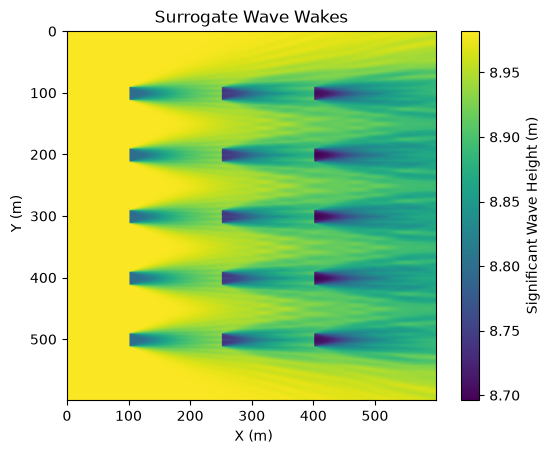

Power of Farm: 4251.8004345842 KW
Power of Farm: 4215.429407 KW


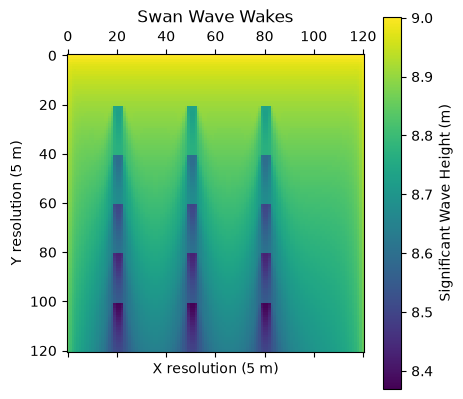

Waves are always from left to right. To test the Farm in a new direction
To simulate different wind directions, the farm is rotated
In the First simulation, wave_direction is 0, and corresponds with West to East
the below example is wave_direction = 0, with waves going from  North to South


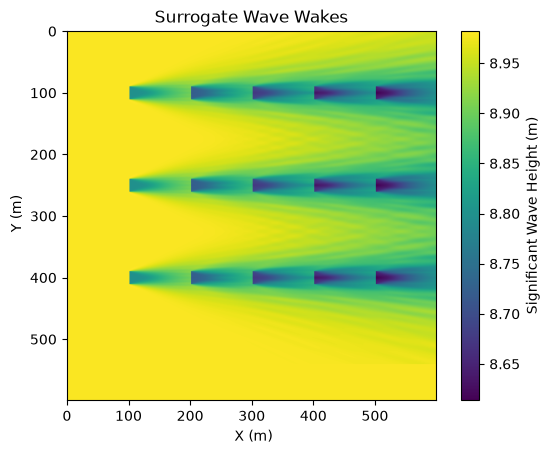

Power of Farm: 4251.801026118605 KW


In [ ]:
# import dependencies
import sys
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt


#fixing local environment variables in jupyter notebook

root_dir = Path.cwd().parent.parent
sys.path.append(f"{root_dir}/wesl/optimizer/offshore_system/wave_system")

#import surrogate model and original snl-swan
from point_absorber_farm import surrogate_swan
# MUST COMPILE SNL-SWAN ON YOUR MACHINE FOR THE FOLLOWING TO WORK
from snl_swan_wrapper import snl_swan

# define x and y coords of wec devices
# note that due to matrix indexing, x_coords is vertical and y_coords is horizontal
# may be changed in future
    
x_coords = [101, 201, 301, 401, 501,
            101, 201, 301, 401, 501,
            101, 201, 301, 401, 501]

y_coords = [101, 101, 101, 101, 101,
            251, 251, 251, 251, 251,
            401, 401, 401, 401, 401]


# grid size of surrogate_swan
horizontal_grid = 600
vertical_grid = 600

period = 10
wave_height = 9

# option to create similar sized SNL-SWAN simulation 
# CAUTION: May trigger Out Of Memory Killer 
comparison = False

surrogate = surrogate_swan(x_coords=x_coords,y_coords=y_coords, grid_y=horizontal_grid, grid_x=vertical_grid)


surrogate.evaluate(wave_height = wave_height, wave_period = period)

print(f"Power of Farm: {surrogate.get_last_power() / 1000} KW")

if comparison == True:
    swan = snl_swan(wec_type=0, wec_x_coords=x_coords, wec_y_coords=y_coords, resolution= 1, wave_direction=0, significant_wave_height = wave_height, wave_period = period, grid_size_x=horizontal_grid, grid_size_y=vertical_grid)
    swan.create_input_file()
    swan.run()
    swan.plot_wakes()

    # once simulated, wakes are populated. If you try to get wakes before simulating, you will get nonsense data 
    wake_diffs = swan.get_wakes()-surrogate.get_wakes()

    plt.figure()
    plt.imshow(wake_diffs)
    plt.title("Absoluate Wake Diffs, Snl-Swan - Surrogate ")
    plt.colorbar(label='Height Difference in Meters')

    percent_err_wakes = np.divide(wake_diffs, swan.get_wakes())
    percent_err_wakes = percent_err_wakes * 100
    plt.figure()
    plt.imshow(percent_err_wakes)
    plt.title("Percent Wake Diffs, Snl-Swan - Surrogate ")
    plt.colorbar(label='Height Difference in %')
    plt.show()
else:
    swan = snl_swan(wec_type=0, wec_x_coords=x_coords, wec_y_coords=y_coords, resolution= 5, wave_direction=0, significant_wave_height = wave_height, wave_period = period, grid_size_x=horizontal_grid, grid_size_y=vertical_grid)
    swan.create_input_file()
    swan.run()
    print(f"Power of Farm: {swan.calculate_total_power() / 1000} KW")
    # swan.plot_wakes()



print("Waves are always from left to right. To test the Farm in a new direction")
print("To simulate different wind directions, the farm is rotated")
print("In the First simulation, wave_direction is 0, and corresponds with West to East")
print("the below example is wave_direction = 0, with waves going from  North to South")

surrogate.evaluate(wave_height = wave_height, wave_period = period, wave_direction = 90)

print(f"Power of Farm: {surrogate.get_last_power() / 1000} KW")


References:

[1] Rasul Satymov, Dmitrii Bogdanov, Mojtaba Dadashi, George Lavidas, Christian Breyer,
Techno-economic assessment of global and regional wave energy resource potentials and profiles in hourly resolution,
Applied Energy,
Volume 364,
2024,
123119,
ISSN 0306-2619,
https://doi.org/10.1016/j.apenergy.2024.123119.

[2] Levi Kilcher, Gabriel García Medina, Zhaoqing Yang,
A scalable wave resource assessment methodology: Application to U.S. waters,
Renewable Energy,
Volume 217,
2023,
119094,
ISSN 0960-1481,
https://doi.org/10.1016/j.renene.2023.119094.

[3] Neary, V., Yu, Y., Epler, J., Shoele, K., Previsic, M., Lawson, M., & Li, Y. (2014). Reference Model 3 Scaled Geometry (RM3: Wave Point Absorber). [Data set]. Marine and Hydrokinetic Data Repository. Sandia National Laboratories. https://doi.org/10.15473/1818910